In [ ]:
from google.colab import drive
drive.mount('/content/drive')
csv_path = "/content/drive/MyDrive/Colab Notebooks/creditcard.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


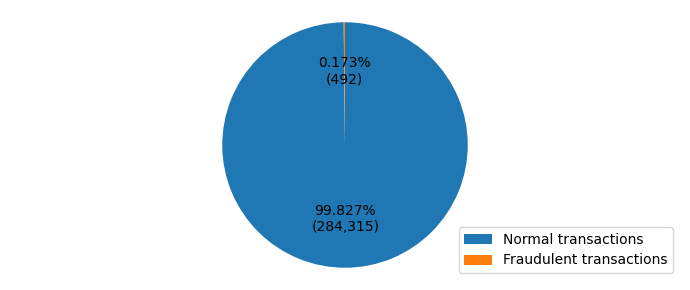

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv(csv_path)

# Basic info about the raw dataset
print(df.shape)
print(df['Class'].value_counts())
print(df.isna().sum())

class_counts = df['Class'].value_counts().sort_index()
colors = ['#1f77b4', '#ff7f0e']   # 0: normal, 1: fraud

total = class_counts.sum()

# Pie üzerindeki yazı: yüzde + adet
def autopct_fmt(pct):
    count = int(round(pct * total / 100.0))
    return f'{pct:.3f}%\n({count:,})'

plt.figure(figsize=(7, 3))

plt.pie(
    class_counts,
    colors=colors,
    autopct=autopct_fmt,   # sadece yüzde + adet
    startangle=90,
    counterclock=False
)
plt.axis('equal')

# Sağ alt köşe legend: yeşil = Normal, kırmızı = Fraud
legend_elements = [
    Patch(facecolor='#1f77b4', label='Normal transactions'),
    Patch(facecolor='#ff7f0e',   label='Fraudulent transactions')
]

plt.legend(handles=legend_elements,
           loc='lower right')

plt.tight_layout()
plt.show()


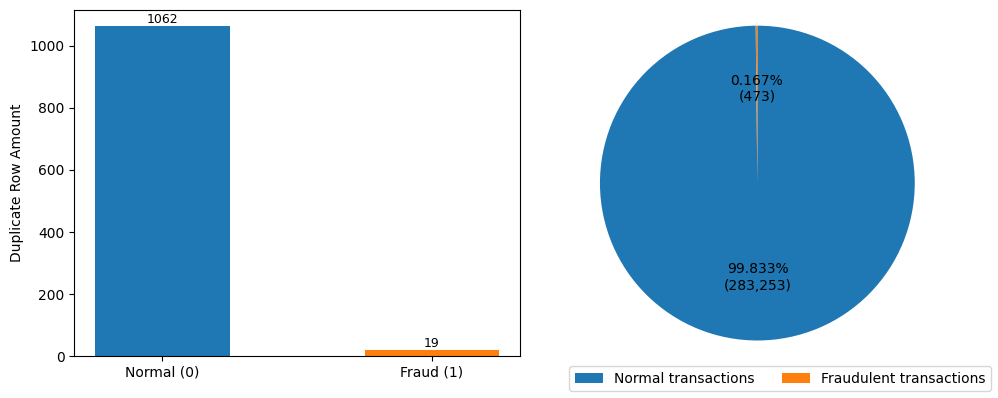

In [ ]:
df_raw = pd.read_csv(csv_path)

# 1) Orijinal sınıf sayıları
class_before = df_raw['Class'].value_counts().sort_index()

# 2) Duplicate'ları sil
df = df_raw.drop_duplicates()

# 3) Silindikten sonraki sınıf sayıları
class_after = df['Class'].value_counts().sort_index()

# 4) Kaç satır silinmiş? (class bazında)
dup_counts = (class_before - class_after).reindex([0, 1]).fillna(0).astype(int)

colors = ['#1f77b4', '#ff7f0e']   # 0: normal, 1: fraud

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ========= SOL: Duplicate row sayıları (dikey bar) =========
ax0 = axes[0]
ax0.bar(['Normal (0)', 'Fraud (1)'], dup_counts[[0, 1]], color=colors, width=0.5)

for i, v in enumerate(dup_counts[[0, 1]]):
    ax0.text(i, v, f'{v}', ha='center', va='bottom', fontsize=9)

ax0.set_ylabel('Duplicate Row Amount')

# ========= SAĞ: drop_duplicates sonrası dağılım (pie chart) =========
ax1 = axes[1]
labels = ['Normal (0)', 'Fraud (1)']
total = class_after.sum()

def autopct_fmt(pct):
    count = int(round(pct * total / 100.0))
    return f'{pct:.3f}%\n({count:,})'

ax1.pie(
    class_after,
    colors=colors,
    autopct=autopct_fmt,
    startangle=90,
    counterclock=False
)
ax1.axis('equal')

# İsteğe bağlı: ortak legend (alt köşe)
legend_elements = [
    Patch(facecolor='#1f77b4', label='Normal transactions'),
    Patch(facecolor='#ff7f0e',   label='Fraudulent transactions')
]
fig.legend(handles=legend_elements, loc='lower right', ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
# ---- Train / Validation / Test split for normal data ----

feature_cols = [c for c in df.columns if c != 'Class']

normal_df = df[df['Class'] == 0].copy()
fraud_df  = df[df['Class'] == 1].copy()

normal_df = normal_df.sort_values('Time')

# Use the first 70% of normal transactions as the base for train+validation
split_idx = int(0.7 * len(normal_df))
train_normal = normal_df.iloc[:split_idx]

# From this 70%, take 80% as train and 20% as validation (random shuffle)
train_normal, val_normal = train_test_split(
    train_normal,
    test_size=0.2,
    shuffle=True,
    random_state=42  # For reproducibility
)

# The remaining 30% of normal transactions are reserved for the test set
test_normal = normal_df.iloc[split_idx:]

# Final test set: normal test samples + ALL fraud samples
# (highly imbalanced, realistic evaluation scenario)
test_df = pd.concat([test_normal, fraud_df], axis=0)


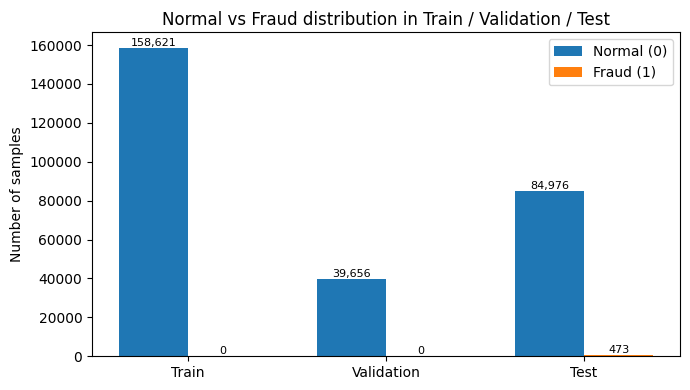

In [ ]:
import numpy as np

# Her setteki normal / fraud sayıları
train_counts = train_normal['Class'].value_counts().reindex([0, 1], fill_value=0)
val_counts   = val_normal['Class'].value_counts().reindex([0, 1], fill_value=0)
test_counts  = test_df['Class'].value_counts().reindex([0, 1], fill_value=0)

splits = ['Train', 'Validation', 'Test']
normal_counts = [train_counts[0], val_counts[0], test_counts[0]]
fraud_counts  = [train_counts[1], val_counts[1], test_counts[1]]

x = np.arange(len(splits))
width = 0.35  # bar genişliği

plt.figure(figsize=(7, 4))
ax = plt.gca()

# Normal ve Fraud barları yan yana
ax.bar(x - width/2, normal_counts, width, label='Normal (0)', color='#1f77b4')
ax.bar(x + width/2, fraud_counts,  width, label='Fraud (1)',  color='#ff7f0e')

# Barların üstüne sayıları yaz
for i, v in enumerate(normal_counts):
    ax.text(x[i] - width/2, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
for i, v in enumerate(fraud_counts):
    ax.text(x[i] + width/2, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel('Number of samples')
ax.set_title('Normal vs Fraud distribution in Train / Validation / Test')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ---- Feature scaling ----

# Initialize a StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on train_normal to avoid data leakage
scaler.fit(train_normal[feature_cols])

# Transform train, validation and test sets using the same scaler
X_train = scaler.transform(train_normal[feature_cols])
X_val   = scaler.transform(val_normal[feature_cols])
X_test  = scaler.transform(test_df[feature_cols])

# True labels for the test set (needed for evaluation of AE and One-Class SVM)
y_test = test_df['Class'].values

# ---- Sanity checks ----

print("Train_normal shape:", train_normal.shape)  # Only normal samples
print("Val_normal shape:", val_normal.shape)      # Only normal samples
print("Test_df shape:", test_df.shape)           # Normal + fraud
print("Test class distribution:\n", test_df['Class'].value_counts())


Train_normal shape: (158621, 31)
Val_normal shape: (39656, 31)
Test_df shape: (85449, 31)
Test class distribution:
 Class
0    84976
1      473
Name: count, dtype: int64


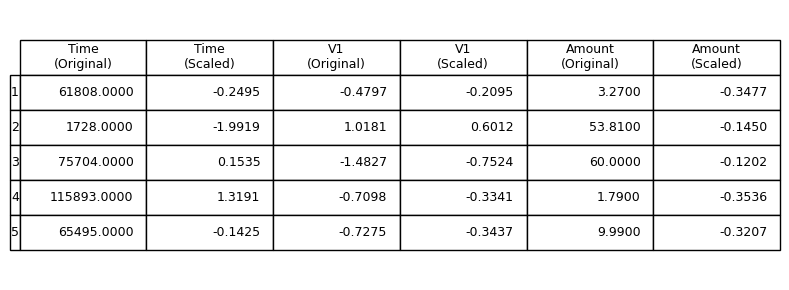

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# İlk 5 satırı al (train_normal'dan)
orig_head   = train_normal[feature_cols].head().reset_index(drop=True)
scaled_head = pd.DataFrame(X_train[:5, :], columns=feature_cols).reset_index(drop=True)

# Çok geniş olmasın diye istersen bazı feature'ları seçebilirsin:
# selected_features = ['Time', 'V1', 'V2', 'V3', 'Amount']
selected_features = ['Time', 'V1' , 'Amount']  # tüm feature'lar için bunu kullan

n_rows = 5
n_feats = len(selected_features)

# --- Hücre içeriği: her satır için [Time-Orig, Time-Scaled, V1-Orig, V1-Scaled, ...] ---
cell_text = []
for i in range(n_rows):
    row_vals = []
    for f in selected_features:
        row_vals.append(f"{orig_head.loc[i, f]:.4f}")   # Original
        row_vals.append(f"{scaled_head.loc[i, f]:.4f}") # Scaled
    cell_text.append(row_vals)

# --- Kolon isimleri: feature + alt başlık (Original / Scaled) ---
col_labels = []
for f in selected_features:
    col_labels.append(f"{f}\n(Original)")
    col_labels.append(f"{f}\n(Scaled)")

row_labels = [1, 2, 3, 4, 5]

# --- Matplotlib tablosu ---
fig, ax = plt.subplots(figsize=(max(8, n_feats*1.4), 3))
ax.axis('off')

table = ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)  # satır yüksekliğini biraz arttırır
plt.tight_layout()
plt.show()
